In [1]:
# from dotenv import load_dotenv
# load_dotenv()

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str
    answer: str

    # 필요한 노드 ? 
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str  # 공제액 
    market_ratio: str  # 공정시장가액비율
    tax_base: str   # 과세표준 계산
    

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=100, separators=["\n\n", "\n"])

In [4]:
from langchain_community.document_loaders import TextLoader

text_path = './docs/real_estate_tax.txt'
loader = TextLoader(text_path,  encoding='utf-8')  # ✅ 인코딩 명시! : 에러 발생함
document_list = loader.load_and_split(text_splitter)

In [5]:
# 과세표준을 계산하는 방법은 vector 스토어에 있다. retriever 부터 생성하자

from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# 벡터 스토어 생성 
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")


vector_store = Chroma.from_documents(
    documents = document_list,
    embedding=embeddings,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection' 
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  

In [6]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [7]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")  # 답변이 잘 안나오는데는 mini 모델을 써서 그럴수도 있다. (원래 gpt-4o 사용)
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [8]:
from langchain_classic import hub

rag_prompt = hub.pull('rlm/rag-prompt')



In [9]:
# 수식을 가져오는 노드 생성
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

tax_base_equation_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요."),
        ("human", "{tax_base_equation_information}")
    ]
)

tax_base_retrieval_chain = (
    {'context': retriever, 'question' : RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)


tax_base_equation_chain = (
    {'tax_base_equation_information' : RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산 시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)    # chain 앞에 {'context': retriever} 가 추가되었으므로, context키는 삭제해도됨
    return {'tax_base_equation': tax_base_equation}


In [10]:
get_tax_base_equation({})

# 생성된 답변은 아래와 같다
# {'tax_base_equation': '주택에 대한 종합부동산세의 과세표준은 납세의무자가 소유한 주택의 공시가격 합산액에서 특정 금액을 공제한 후, 공정시장가액비율을 곱하여 계산합니다. 이 비율은 부동산 시장 동향과 지방 여건을 고려하여 60%에서 100% 사이로 대통령령으로 결정됩니다. 또한, 1세대 1주택자는 12억 원, 법인 또는 법인으로 보는 단체는 6억 원, 일반적으로는 9억 원까지의 합산액이 기준이 됩니다.'}

# 그런데, 줄글로 되어있으면 LLM이 알아듣기 힘들 수 도 있다. 
# 1. 그래서 query 에 "계산하는 방법을 수식으로 표현해서 알려주세요'" 라고 명확히 물어봤지만, 그래도 답변이 수식이 아니라 줄글로 나옴
# 2. 아래 셀을 생각해보자




# {'tax_base_equation': '과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율'}

{'tax_base_equation': '\\[\n\\\\text{과세표준} = \\\\text{주택의 공시지가}\n\\]'}

In [11]:
# 2.
# LLM에 여러 태스크를 한번에 주면, LLM이 헤맨다
# 번역, 요약, 분석에 능하다. 그런데, "분석해서 요약해서 번역해줘 " -> 결과가 안나오는 이유


# chain을 하나 더 만들어서 tax_base_equation 으로 가져온 정보에 기반으로 수식만 추출하게끔 짠다

In [12]:
# 공제액을 찾는 노드


tax_deduction_chain = (
    {'context': retriever, 'question' : RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산 시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)    # chain 앞에 {'context': retriever} 가 추가되었으므로, context키는 삭제해도됨
    return {'tax_deduction': tax_deduction}


In [13]:
get_tax_deduction({})


# {'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억원, 법인 및 법인으로 보는 단체는 6억원, 일반적인 경우 9억원입니다. 또한 만 60세 이상인 1세대 1주택자는 연령에 따라 20%, 30%, 40%의 공제율이 적용됩니다.'}

{'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 다음과 같습니다: 1세대 1주택자는 12억원, 법인 또는 법인으로 보는 단체는 6억원, 그리고 그 외의 경우는 9억원입니다. 이 금액들은 납세의무자별로 주택의 공시가격에서 공제됩니다.'}

In [14]:
# 주택에 대한 공정시장가액비율
# 대통령령이라서 웹 서치를 해야함 


# web-search 노드
# from langchain_tavily import TavilySearch
from langchain_community.tools import TavilySearchResults   # cannot import 에러
# from langchain_community.tools import TavilySearch   # cannot import 에러
from datetime import date


tavily_search_tool = TavilySearchResults(
    max_results=5, 
    include_answer=True,
    include_raw_content=True,
    include_images=True,
    search_depth="advanced",
    
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", f"아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}"),
        ("human", "{query}")
    ]
)

def get_market_ratio(state: AgentState):
    query = f'오늘 날짜: ({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇 %인가요'
    context = tavily_search_tool.invoke(query)  
    print(f'context == {context}')
    tax_market_ratio_chain = tax_market_ratio_prompt | llm | StrOutputParser()
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    return {'market_ratio' : market_ratio}  


C:\Users\KE126\AppData\Local\Temp\ipykernel_29352\2424218897.py:12: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(


In [15]:
get_market_ratio({})

# {'market_ratio': '2026년 3월 18일 기준 주택의 공정시장가액비율은 60%로 설정되어 있습니다. 이는 법적으로 정해진 범위에 따른 것으로, 특정한 조건에 따라 다른 비율이 적용될 수도 있지만, 기본적인 설정은 60%입니다.'}
# 23년이 gpt 학습날짜 컷오프다. - 지금 24년도니까, 프롬프트에 "날짜정보"를 주도록 하자

context == [{'title': '2026년 공시가격 18일 공개…"시세변동분만 반영" - Daum', 'url': 'https://v.daum.net/v/7Gw5ct4qaT', 'content': '닫기\n\n공시가격 현실화율 69%…전년 동일\n\n서울 중구 남산에서 바라본 아파트 모습. 뉴시스\n\n \n\n[파이낸셜뉴스] 올해 공동주택 공시가격 열람이 이달 시작된다. 공시가격 현실화율은 69%로 지난해와 같다.\n\n국토교통부는 올해 1월 1일 기준으로 조사·산정한 공동주택(약 1585만가구)의 공시가격안에 대한 소유자 열람과 의견청취 절차를 오는 18일부터 다음 달 6일까지 20일간 진행한다고 13일 밝혔다.\n\n최종 결정·공시는 4월 30일 예정이다.\n\n올해 공시가격은 2026년 부동산 가격 공시 추진방안에 따라 지난해와 동일한 현실화율 69%를 적용했다.\n\n지난해와 같은 현실화율이 유지되면서 시세 변동분만 반영해 공동주택 공시가격이 산정될 예정이다.\n\ngoing@fnnews.com 최가영 기자\n\nCopyright © 파이낸셜뉴스. 무단전재 및 재배포 금지.\n\n파이낸셜뉴스에서 직접 확인하세요. 해당 언론사로 이동합니다. [...] ## 경제\n\n### 2026년 공시가격 18일 공개…"시세변동분만 반영"\n\n최가영 2026. 3. 13. 10:35\n\n자동요약 기사 제목과 주요 문장을 기반으로 자동요약한 결과입니다.  \n 전체 맥락을 이해하기 위해서는 본문 보기를 권장합니다.\n\n올해 공동주택 공시가격 열람이 이달 시작된다.\n\n국토교통부는 올해 1월 1일 기준으로 조사·산정한 공동주택(약 1585만가구)의 공시가격안에 대한 소유자 열람과 의견청취 절차를 오는 18일부터 다음 달 6일까지 20일간 진행한다고 13일 밝혔다.\n\n올해 공시가격은 2026년 부동산 가격 공시 추진방안에 따라 지난해와 동일한 현실화율 69%를 적용했다.\n\n지난해와 같은 현실화율이 유지되면서 시세 변동분만 반영해 공동주택 공시가격이

{'market_ratio': '2026년 3월 18일에 해당하는 주택 공시가격 공정시장가액비율은 69%입니다. 이는 해당 날짜의 뉴스 기사에서 확인된 정보입니다.'}

In [16]:
from langchain_core.prompts import ChatPromptTemplate

tax_base_caculation_prompt = ChatPromptTemplate.from_messages([

    ('system', '''
        주어진 내용을 기반으로 과세표준을 계산해주세요
                                                                
        과세표준 계산 공식: {tax_base_equation}
        공제금액: {tax_deduction}
        공정시장가액비율: {market_ratio}
        사용자 주택 공시가격 정보 : {query}'''),

    ('human', '사용자 주택 공시가격 정보 : {query}')

])

    
    
    
    
    

def calculate_tax_base(state: AgentState):
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']

    query = state['query']

    # 체인 생성
    tax_base_caculation_chain =    tax_base_caculation_prompt | llm | StrOutputParser()
    tax_base = tax_base_caculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })
    print(f'tax_base == {tax_base}')
    return {'tax_base': tax_base}


In [17]:
initial_state = {
    'query': query,
    'tax_base_equation': '과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억원, 법인 및 법인으로 보는 단체는 6억원, 일반적인 경우 9억원입니다. 또한 만 60세 이상인 1세대 1주택자는 연령에 따라 20%, 30%, 40%의 공제율이 적용됩니다.',
    'market_ratio': '2026년 3월 18일 기준 주택의 공정시장가액비율은 60%로 설정되어 있습니다. 이는 법적으로 정해진 범위에 따른 것으로, 특정한 조건에 따라 다른 비율이 적용될 수도 있지만, 기본적인 설정은 60%입니다.'
    
    }

In [18]:
calculate_tax_base(initial_state)

tax_base == 주택 공시가격 정보에 따라 과세표준을 계산해보겠습니다.

1. **주택 공시가격 합산**:
   - 5억짜리 집 1채: 5억원
   - 10억짜리 집 1채: 10억원
   - 20억짜리 집 1채: 20억원
   - 합산: 5억원 + 10억원 + 20억원 = 35억원

2. **공제금액**:
   - 일반적인 경우의 공제금액은 9억원입니다. (1세대 1주택자가 아니므로 12억원 공제는 적용되지 않음)

3. **과세표준 계산**:
   - 과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율
   - 과세표준 = (35억원 - 9억원) × 60%
   - 과세표준 = (26억원) × 0.6 = 15.6억원

따라서 해당 사용자가 납부해야 할 과세표준은 15.6억원입니다. 

세금 계산은 과세표준에 따라 세율이 적용되며, 세율은 총 보유 가치 또는 세법에 따라 달라질 수 있습니다. 구체적인 세율이나 추가적인 정보가 필요하다면, 해당 세율에 따라 추가 계산이 가능하므로 참고해주세요.


{'tax_base': '주택 공시가격 정보에 따라 과세표준을 계산해보겠습니다.\n\n1. **주택 공시가격 합산**:\n   - 5억짜리 집 1채: 5억원\n   - 10억짜리 집 1채: 10억원\n   - 20억짜리 집 1채: 20억원\n   - 합산: 5억원 + 10억원 + 20억원 = 35억원\n\n2. **공제금액**:\n   - 일반적인 경우의 공제금액은 9억원입니다. (1세대 1주택자가 아니므로 12억원 공제는 적용되지 않음)\n\n3. **과세표준 계산**:\n   - 과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율\n   - 과세표준 = (35억원 - 9억원) × 60%\n   - 과세표준 = (26억원) × 0.6 = 15.6억원\n\n따라서 해당 사용자가 납부해야 할 과세표준은 15.6억원입니다. \n\n세금 계산은 과세표준에 따라 세율이 적용되며, 세율은 총 보유 가치 또는 세법에 따라 달라질 수 있습니다. 구체적인 세율이나 추가적인 정보가 필요하다면, 해당 세율에 따라 추가 계산이 가능하므로 참고해주세요.'}

In [19]:

tax_rate_caculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요
     종합부동산세 세율: {context}'''),

    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
     
    과세표준 : {tax_base}
    주택 수 : {query}''')

])

def calculate_tax_rate(state: AgentState):
    
    # retrieve -> 사용자 질문 기반 (세율 정보를 검색해서 가지고 옴) => [세율 정보]
    # 과세표준, [세율 정보]와 같이 LLM에 던진다 
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)  # 사용자 질문
    
    tax_rate_chain = (
        tax_rate_caculation_prompt | llm | StrOutputParser()
    )

    tax_rate = tax_rate_chain.invoke({
        'context' : context,
        'tax_base':tax_base,
        'query' : query
    })

    print(f'tax_rate == {tax_rate}')
    return {'answer': tax_rate}




In [20]:
# {'tax_base': '주택 공시가격 정보를 바탕으로 과세표준을 계산해보겠습니다.\n\n1. **주택 공시가격 합산**:\n   - 5억 + 10억 + 20억 = 35억\n\n2. **공제금액 결정**:\n   - 일반적인 경우에 해당하므로 9억원을 공제합니다.\n\n3. **공제된 과세표준 계산**:\n   - 과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율\n   - 과세표준 = (35억 - 9억) × 60%\n   - 과세표준 = (26억) × 60% = 15.6억\n\n따라서, 이 사용자는 15.6억 원의 과세표준으로 종합부동산세를 계산하게 됩니다. \n\n이제 세금 산출을 위해 종합부동산세 세율을 적용해야 하는데, 실제 세율은 해당 과세표준에 따라 차등적으로 적용됩니다. 2022년 기준, 1세대 1주택자의 경우 1.0%의 세율이 일반적으로 적용되지만 세율은 변동할 수 있습니다.\n\n4. **종합부동산세 예시 계산**:\n   - 세금 = 과세표준 × 세율\n   - 세금 = 15.6억 × 1% = 1560만원\n\n결론적으로, 주택 공시가격이 35억원인 경우의 대략적인 종합부동산세는 약 1560만원입니다. \n(실제 세율은 변동할 수 있으므로, 정확한 계산은 최신 세법에 따라 확인해야 합니다.)'}
tax_base_state = {'tax_base': '주택 공시가격 정보를 바탕으로 과세표준을 계산해보겠습니다.\n\n1. **주택 공시가격 합산**:\n   - 5억 + 10억 + 20억 = 35억\n\n2. **공제금액 결정**:\n   - 일반적인 경우에 해당하므로 9억원을 공제합니다.\n\n3. **공제된 과세표준 계산**:\n   - 과세표준 = (주택 공시가격 합산 - 공제금액) × 공정시장가액비율\n   - 과세표준 = (35억 - 9억) × 60%\n   - 과세표준 = (26억) × 60% = 15.6억\n\n따라서, 이 사용자는 15.6억 원의 과세표준으로 종합부동산세를 계산하게 됩니다. \n\n이제 세금 산출을 위해 종합부동산세 세율을 적용해야 하는데, 실제 세율은 해당 과세표준에 따라 차등적으로 적용됩니다. 2022년 기준, 1세대 1주택자의 경우 1.0%의 세율이 일반적으로 적용되지만 세율은 변동할 수 있습니다.\n\n4. **종합부동산세 예시 계산**:\n   - 세금 = 과세표준 × 세율\n   - 세금 = 15.6억 × 1% = 1560만원\n\n결론적으로, 주택 공시가격이 35억원인 경우의 대략적인 종합부동산세는 약 1560만원입니다. \n(실제 세율은 변동할 수 있으므로, 정확한 계산은 최신 세법에 따라 확인해야 합니다.)', 'query': query}


In [21]:
calculate_tax_rate(tax_base_state)

tax_rate == 사용자가 가지고 있는 주택 수가 3채(5억, 10억, 20억)로, 3주택 이상을 소유하고 있습니다. 이에 따라 3주택 이상에 적용되는 종합부동산세 세율을 사용해야 합니다.

앞서 계산한 과세표준은 15.6억 원입니다. 이를 바탕으로 종합부동산세를 계산해 보겠습니다.

### 3주택 이상에 대한 세율 적용:

| 과세표준              | 세율                                  |
|---------------------|-------------------------------------|
| 3억 원 이하           | 1천분의 5                              |
| 3억 원 초과 6억 원 이하 | 150만 원 + (3억 원을 초과하는 금액의 1천분의 7)  |
| 6억 원 초과 12억 원 이하 | 360만 원 + (6억 원을 초과하는 금액의 1천분의 10) |
| 12억 원 초과 25억 원 이하 | 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)|
| 25억 원 초과 50억 원 이하 | 3천560만 원 + (25억 원을 초과하는 금액의 1천분의 30)|
| 50억 원 초과 94억 원 이하 | 1억1천600만 원 + (50억 원을 초과하는 금액의 1천분의 40)|
| 94억 원 초과          | 2억8천660만 원 + (94억 원을 초과하는 금액의 1천분의 50)|

### 15.6억 원의 과세표준에 대한 세금 계산:

1. **25억 원 초과 50억 원 이하 구간에 해당**:
   - 기본 세액: 3천560만 원
   - 초과 부분: 15.6억 원 - 25억 원 = -9.4억 원 (이 경우는 해당 없음)

2. **12억 원 이하 부분 세액 계산**:
   - 12억 원 초과 구간: 15.6억 원 - 12억 원 = 3.6억 원
   - 세액: 960만 원 + (3.6억 원 × 1천분의 20)

   \[
   세액 = 960만원 + (3.6억 원 × 0

{'answer': '사용자가 가지고 있는 주택 수가 3채(5억, 10억, 20억)로, 3주택 이상을 소유하고 있습니다. 이에 따라 3주택 이상에 적용되는 종합부동산세 세율을 사용해야 합니다.\n\n앞서 계산한 과세표준은 15.6억 원입니다. 이를 바탕으로 종합부동산세를 계산해 보겠습니다.\n\n### 3주택 이상에 대한 세율 적용:\n\n| 과세표준              | 세율                                  |\n|---------------------|-------------------------------------|\n| 3억 원 이하           | 1천분의 5                              |\n| 3억 원 초과 6억 원 이하 | 150만 원 + (3억 원을 초과하는 금액의 1천분의 7)  |\n| 6억 원 초과 12억 원 이하 | 360만 원 + (6억 원을 초과하는 금액의 1천분의 10) |\n| 12억 원 초과 25억 원 이하 | 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)|\n| 25억 원 초과 50억 원 이하 | 3천560만 원 + (25억 원을 초과하는 금액의 1천분의 30)|\n| 50억 원 초과 94억 원 이하 | 1억1천600만 원 + (50억 원을 초과하는 금액의 1천분의 40)|\n| 94억 원 초과          | 2억8천660만 원 + (94억 원을 초과하는 금액의 1천분의 50)|\n\n### 15.6억 원의 과세표준에 대한 세금 계산:\n\n1. **25억 원 초과 50억 원 이하 구간에 해당**:\n   - 기본 세액: 3천560만 원\n   - 초과 부분: 15.6억 원 - 25억 원 = -9.4억 원 (이 경우는 해당 없음)\n\n2. **12억 원 이하 부분 세액 계산**:\n   - 12억 원 초과 구간: 15.6억 원 - 12억 원 = 3.6억 원\n   - 세액: 960만 원 + (3.6억 원 × 1천분의 20)\n\n   \\[\

In [22]:
# 노드, 엣지 추가

graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [23]:
# 엣지 추가

from langgraph.graph import START, END


graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')

graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')


graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

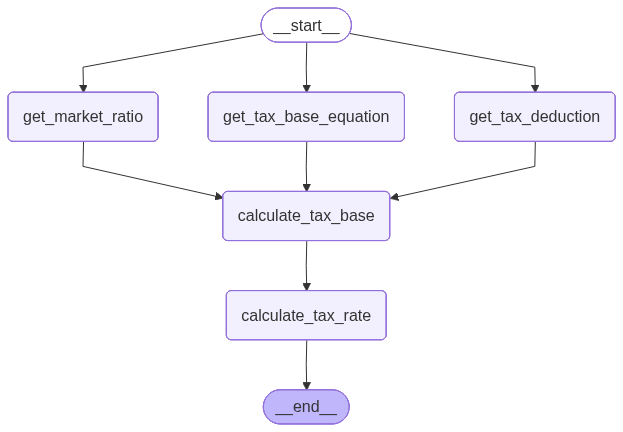

In [24]:
from IPython.display import Image, display

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))  

# income_tax_agent, web_generate -> 좋은 LLM 모델을 쓰고
# income_tax_agent가 서브 그래프


In [25]:
# initial state
initial_state = {'query':query}

graph.invoke(initial_state)

context == [{'title': '2026년 공시가격 18일 공개…"시세변동분만 반영" - Daum', 'url': 'https://v.daum.net/v/7Gw5ct4qaT', 'content': '닫기\n\n공시가격 현실화율 69%…전년 동일\n\n서울 중구 남산에서 바라본 아파트 모습. 뉴시스\n\n \n\n[파이낸셜뉴스] 올해 공동주택 공시가격 열람이 이달 시작된다. 공시가격 현실화율은 69%로 지난해와 같다.\n\n국토교통부는 올해 1월 1일 기준으로 조사·산정한 공동주택(약 1585만가구)의 공시가격안에 대한 소유자 열람과 의견청취 절차를 오는 18일부터 다음 달 6일까지 20일간 진행한다고 13일 밝혔다.\n\n최종 결정·공시는 4월 30일 예정이다.\n\n올해 공시가격은 2026년 부동산 가격 공시 추진방안에 따라 지난해와 동일한 현실화율 69%를 적용했다.\n\n지난해와 같은 현실화율이 유지되면서 시세 변동분만 반영해 공동주택 공시가격이 산정될 예정이다.\n\ngoing@fnnews.com 최가영 기자\n\nCopyright © 파이낸셜뉴스. 무단전재 및 재배포 금지.\n\n파이낸셜뉴스에서 직접 확인하세요. 해당 언론사로 이동합니다. [...] ## 경제\n\n### 2026년 공시가격 18일 공개…"시세변동분만 반영"\n\n최가영 2026. 3. 13. 10:35\n\n자동요약 기사 제목과 주요 문장을 기반으로 자동요약한 결과입니다.  \n 전체 맥락을 이해하기 위해서는 본문 보기를 권장합니다.\n\n올해 공동주택 공시가격 열람이 이달 시작된다.\n\n국토교통부는 올해 1월 1일 기준으로 조사·산정한 공동주택(약 1585만가구)의 공시가격안에 대한 소유자 열람과 의견청취 절차를 오는 18일부터 다음 달 6일까지 20일간 진행한다고 13일 밝혔다.\n\n올해 공시가격은 2026년 부동산 가격 공시 추진방안에 따라 지난해와 동일한 현실화율 69%를 적용했다.\n\n지난해와 같은 현실화율이 유지되면서 시세 변동분만 반영해 공동주택 공시가격이

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '사용자가 보유한 주택의 공정시장가액과 과세표준을 바탕으로 종합부동산세를 계산하겠습니다.\n\n1. **주택 공시가격 정보**:\n   - 5억 원짜리 집 1채\n   - 10억 원짜리 집 1채\n   - 20억 원짜리 집 1채\n\n2. **공정시장가액 비율 적용**:\n   - 5억 원: 44% → 공정시장가액 = 5억 원 × 0.44 = 2.2억 원 (22,000,000 원)\n   - 10억 원: 45% → 공정시장가액 = 10억 원 × 0.45 = 4.5억 원 (45,000,000 원)\n   - 20억 원: 45% → 공정시장가액 = 20억 원 × 0.45 = 9억 원 (90,000,000 원)\n\n3. **총 공정시장가액**: \n   - 22,000,000 원 + 45,000,000 원 + 90,000,000 원 = 157,000,000 원 (1억 5천 7백만 원)\n\n4. **공제금액**: \n   - 1세대 1주택자가 아닌 경우, 해당 주택의 공제금액은 9억 원입니다.\n\n5. **과세표준 계산**: \n   - 총 공정시장가액에서 공제금액을 차감합니다.\n   - 157,000,000 원 - 90,000,000 원 = 67,000,000 원 (6억 7천만 원)\n\n6. **과세표준을 통해 세금 계산**:\n   - 과세표준이 3억 원을 초과하므로 세금 구간에 따라 계산합니다.\n   - 과세표준이 3억 원을 초과한 부분에 대해 세금 계산:\n\n   - 기본 세금: 150만 원 (3억 원 이하에 대한 세금)\n   - 초과 금액: 67,000,000 원 - 30,000,000 원 = 37,000,000 원\n\n   추가 세금:\n   \\[\n   \\text{추가 세금} = 37,000,000 \\times 0.001 = 37,000 원\n   \\]\n\n7. **최종 세금 계산**:\

#### small LLM

In [ ]:
# 간단해 보이는, 작은 LLM으로 결과가 충분히 나올 것 같은 것들은 바꿔준다. 
# 비용 절감, 속도 향상..